# FSR divider: voltage vs pressure (with 12-bit ADC round-trip)

FSR resistance–force model:

$$R = 1.26 \times 10^6 \cdot F^{-0.807}$$

Hardware:
- Force range: 0.1 N ~ 300 N (step 0.1 N)
- Reference resistor: Rx = 35 kΩ
- Supply: Vcc = 3.3 V
- ADC reads voltage across Rx: $V = V_{cc} \cdot \dfrac{R_x}{R + R_x}$
- 12-bit ADC: raw counts 0–4095, `V = raw × (3.3 / 4096)` (same as `usb_daq_v20`)

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Hardware & FSR model
VCC = 3.3
RX = 100_000.0
K = 1.26e6          # R = K * F^(-alpha)
ALPHA = 0.807
ADC_MAX = 4095
AD_VOLTAGE_SCALE = VCC / 4096.0  # usb_daq_v20/constants.py

F_MIN, F_MAX, F_STEP = 0.1, 300.0, 0.1
forces_n = np.arange(F_MIN, F_MAX + F_STEP / 2, F_STEP)

# Forward: force -> resistance -> ideal voltage
resistance_ohm = K * forces_n ** (-ALPHA)
voltage_ideal_v = VCC * RX / (resistance_ohm + RX)

# Quantize to 12-bit ADC (as firmware/DAQ would report)
adc_raw = np.clip(np.round(voltage_ideal_v / AD_VOLTAGE_SCALE), 0, ADC_MAX).astype(np.int32)
voltage_from_adc_v = adc_raw * AD_VOLTAGE_SCALE

# Inverse: ADC voltage -> resistance -> force
resistance_from_adc = RX * (VCC - voltage_from_adc_v) / np.clip(voltage_from_adc_v, 1e-6, None)
forces_from_adc_n = (K / resistance_from_adc) ** (1.0 / ALPHA)

force_error_n = forces_from_adc_n - forces_n
force_error_pct = 100.0 * force_error_n / forces_n

print(f"Sample count: {len(forces_n)}")
print(f"Ideal voltage: {voltage_ideal_v.min():.4f} ~ {voltage_ideal_v.max():.4f} V  (swing {np.ptp(voltage_ideal_v):.4f} V)")
print(f"ADC raw:       {adc_raw.min()} ~ {adc_raw.max()}  (swing {adc_raw.max() - adc_raw.min()})")
print(f"Quantized V:   {voltage_from_adc_v.min():.4f} ~ {voltage_from_adc_v.max():.4f} V")
print(f"Force error:   {force_error_n.min():+.4f} ~ {force_error_n.max():+.4f} N")
print(f"Force error %: {force_error_pct.min():+.4f}% ~ {force_error_pct.max():+.4f}%  (max abs {np.abs(force_error_pct).max():.4f}%)")

Sample count: 3000
Ideal voltage: 0.0403 ~ 2.9300 V  (swing 2.8897 V)
ADC raw:       50 ~ 3637  (swing 3587)
Quantized V:   0.0403 ~ 2.9302 V
Force error:   -0.4344 ~ +0.4296 N
Force error %: -0.4768% ~ +0.4124%  (max abs 0.4768%)


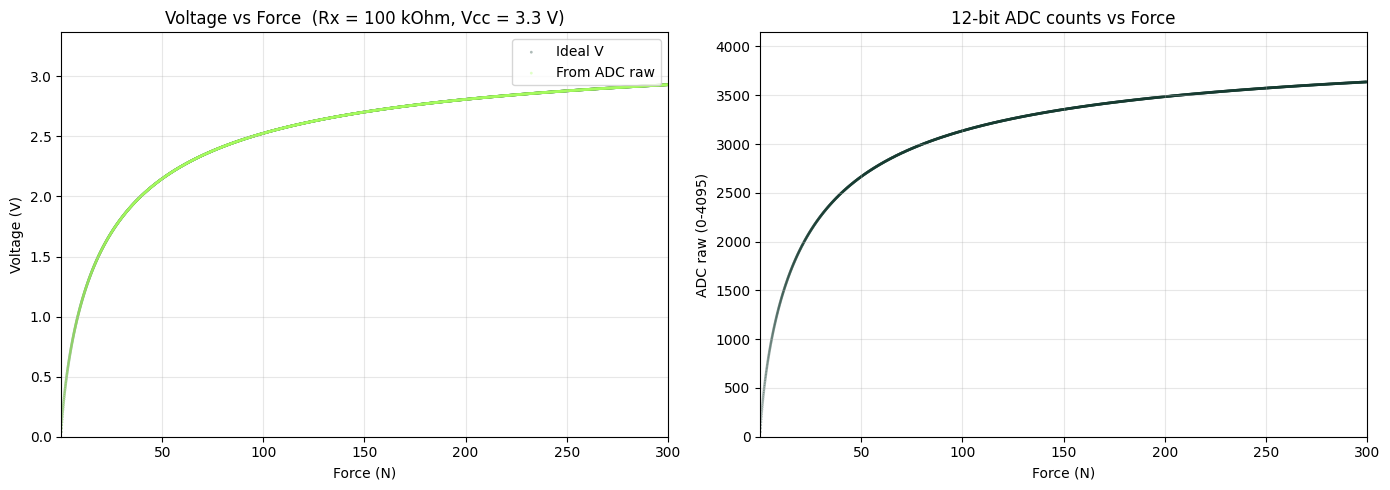

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ideal voltage vs force
ax0 = axes[0]
ax0.scatter(forces_n, voltage_ideal_v, s=4, alpha=0.35, c="#163B31", edgecolors="none", label="Ideal V")
ax0.scatter(forces_n, voltage_from_adc_v, s=4, alpha=0.35, c="#A8FF60", edgecolors="none", label="From ADC raw")
ax0.set_xlabel("Force (N)")
ax0.set_ylabel("Voltage (V)")
ax0.set_title(f"Voltage vs Force  (Rx = {RX/1000:.0f} kOhm, Vcc = {VCC} V)")
ax0.set_xlim(F_MIN, F_MAX)
ax0.set_ylim(0, VCC * 1.02)
ax0.grid(True, alpha=0.3)
ax0.legend(loc="upper right")

# Right: ADC raw vs force
ax1 = axes[1]
ax1.scatter(forces_n, adc_raw, s=4, alpha=0.35, c="#163B31", edgecolors="none")
ax1.set_xlabel("Force (N)")
ax1.set_ylabel("ADC raw (0-4095)")
ax1.set_title("12-bit ADC counts vs Force")
ax1.set_xlim(F_MIN, F_MAX)
ax1.set_ylim(0, ADC_MAX + 50)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

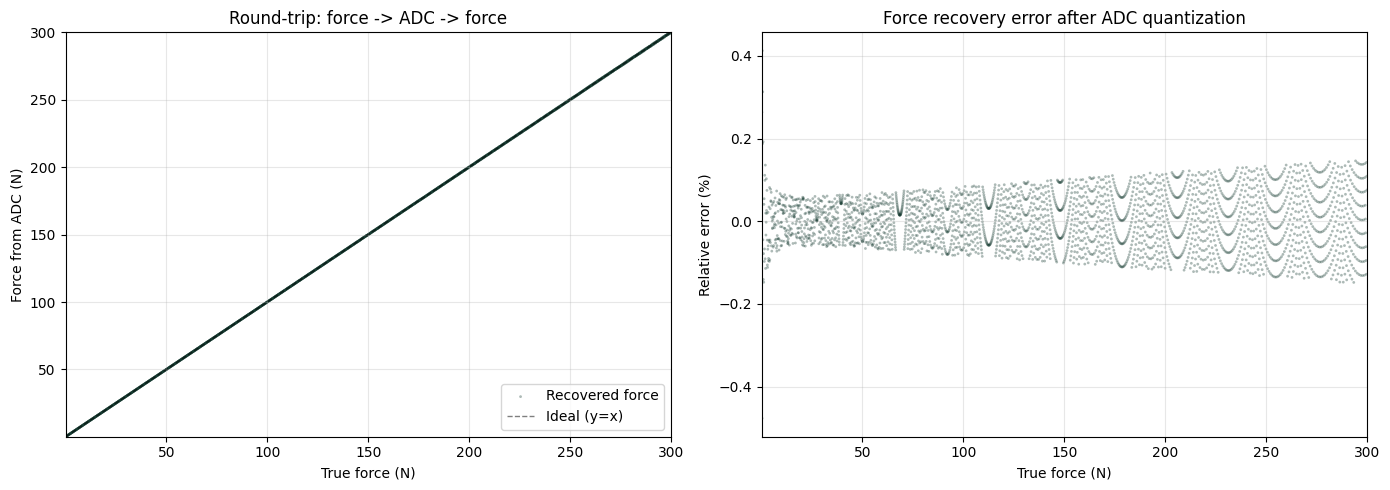

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax0 = axes[0]
ax0.scatter(forces_n, forces_from_adc_n, s=4, alpha=0.35, c="#163B31", edgecolors="none", label="Recovered force")
ax0.plot([F_MIN, F_MAX], [F_MIN, F_MAX], "k--", lw=1, alpha=0.5, label="Ideal (y=x)")
ax0.set_xlabel("True force (N)")
ax0.set_ylabel("Force from ADC (N)")
ax0.set_title("Round-trip: force -> ADC -> force")
ax0.set_xlim(F_MIN, F_MAX)
ax0.set_ylim(F_MIN, F_MAX)
ax0.grid(True, alpha=0.3)
ax0.legend(loc="lower right")

ax1 = axes[1]
ax1.scatter(forces_n, force_error_pct, s=4, alpha=0.35, c="#163B31", edgecolors="none")
ax1.set_xlabel("True force (N)")
ax1.set_ylabel("Relative error (%)")
ax1.set_title("Force recovery error after ADC quantization")
ax1.set_xlim(F_MIN, F_MAX)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()